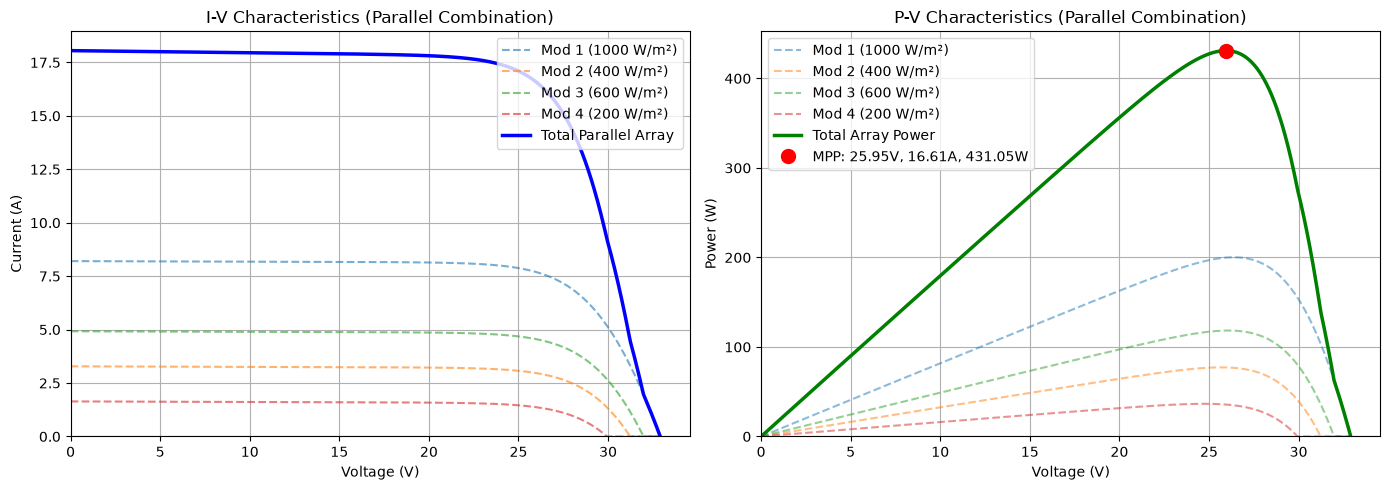

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import newton

k = 1.38e-23   
q = 1.60e-19

Isc = 8.21     
Voc = 32.9 
Ns = 54            
Ki = 0.0032
Kv = -0.123
n = 1.3            

Rsh = 415.405        
Rs = 0.221          
Ion = 9.825e-8    

T = 25 + 273.15
Vt = (Ns * k * T) / q 

def solve_module_current(V_array, G):

    I_pv = (Isc + Ki * (T - 298.15)) * (G / 1000)
    I_o_adj = Ion * ((T / 298.15)**3) * np.exp(((q * 1.12) / (n * k)) * (1/298.15 - 1/T))
    
    I_out = np.zeros_like(V_array)
    
    for i in range(len(V_array)):
        V = V_array[i]
        
        def f(I):
            arg = (V + I * Rs) / (n * Vt)
            arg = np.clip(arg, -50, 50)  
            return I_pv - I_o_adj * (np.exp(arg) - 1) - (V + I * Rs) / Rsh - I

        def df(I):
            arg = (V + I * Rs) / (n * Vt)
            arg = np.clip(arg, -50, 50)
            return -1 - (I_o_adj * Rs / (n * Vt)) * np.exp(arg) - Rs / Rsh

        try:
            sol = newton(f, x0=I_pv, fprime=df, maxiter=100)
            I_out[i] = max(0, sol)  
        except RuntimeError:
            I_out[i] = 0.0         
            
    return I_out

G_levels = [1000, 400, 600, 200] 

V_array = np.linspace(0, Voc, 1000)

I_m1 = solve_module_current(V_array, G_levels[0])
I_m2 = solve_module_current(V_array, G_levels[1])
I_m3 = solve_module_current(V_array, G_levels[2])
I_m4 = solve_module_current(V_array, G_levels[3])


I_parallel_array = I_m1 + I_m2 + I_m3 + I_m4 

P_parallel_array = V_array * I_parallel_array

# Find Maximum Power Point (MPP)
idx_mpp = np.argmax(P_parallel_array)
V_mpp = V_array[idx_mpp]
I_mpp = I_parallel_array[idx_mpp]
P_mpp = P_parallel_array[idx_mpp]

plt.figure(figsize=(14, 5))

# I-V Characteristics
plt.subplot(1, 2, 1)
plt.plot(V_array, I_m1, '--', label=f'Mod 1 ({G_levels[0]} W/m²)', alpha=0.6)
plt.plot(V_array, I_m2, '--', label=f'Mod 2 ({G_levels[1]} W/m²)', alpha=0.6)
plt.plot(V_array, I_m3, '--', label=f'Mod 3 ({G_levels[2]} W/m²)', alpha=0.6)
plt.plot(V_array, I_m4, '--', label=f'Mod 4 ({G_levels[3]} W/m²)', alpha=0.6)

plt.plot(V_array, I_parallel_array, 'b', linewidth=2.5, label='Total Parallel Array')
plt.title('I-V Characteristics (Parallel Combination)')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.grid(True)
plt.legend()
plt.xlim(left=0)
plt.ylim(bottom=0)

#  P-V Characteristics
plt.subplot(1, 2, 2)
plt.plot(V_array, V_array * I_m1, '--', label=f'Mod 1 ({G_levels[0]} W/m²)', alpha=0.5)
plt.plot(V_array, V_array * I_m2, '--', label=f'Mod 2 ({G_levels[1]} W/m²)', alpha=0.5)
plt.plot(V_array, V_array * I_m3, '--', label=f'Mod 3 ({G_levels[2]} W/m²)', alpha=0.5)
plt.plot(V_array, V_array * I_m4, '--', label=f'Mod 4 ({G_levels[3]} W/m²)', alpha=0.5)

plt.plot(V_array, P_parallel_array, 'g', linewidth=2.5, label='Total Array Power')
plt.plot(V_mpp, P_mpp, 'ro', markersize=10, label=f'MPP: {V_mpp:.2f}V, {I_mpp:.2f}A, {P_mpp:.2f}W')
plt.title('P-V Characteristics (Parallel Combination)')
plt.xlabel('Voltage (V)')
plt.ylabel('Power (W)')
plt.grid(True)
plt.legend()
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()